In [ ]:
%load_ext autoreload
%autoreload 2

# Segway Model with Inertia of the pendulum

Originally the model is defined as the pendulum as a point mass, where ineritia is calculated as $I = m R^2$. In this model, the pendulum is defined as rectangular box, where inertia is calculated as $I = \frac{1}{12} m (w_b^2 + h_b^2)$, where $w$ and $h$ are the width and height of the box respectively, which in terms, result in inertia of the pendulum as $I = m R^2 + \frac{1}{12} m (w_b^2 + h_b^2)$.

## Modeling

Previous model use this inertia while calculating Kenetic energy before Lagrangian, which is defined as:
$$
\begin{align}
T &= \frac{1}{2} m (\dot{x}_C^2 + \dot{y}_C^2) + \frac{1}{2} I \dot{\gamma}^2 + \frac{1}{2} m_w (\dot{x}_w^2 ) \\
&= \frac{1}{2} m \left( (\dot{x}_C + h \dot{\gamma} \cos \gamma)^2 + (-h \dot{\gamma} \sin \gamma)^2 \right) + \frac{1}{2} I \dot{\gamma}^2 + \frac{1}{2} m_w \dot{x}_C^2 \\
&= \frac{1}{2} m \left( \dot{x}_C^2 + 2 h \dot{x}_C \dot{\gamma} \cos \gamma + h^2 \dot{\gamma}^2 \right) + \frac{1}{2} I \dot{\gamma}^2 + \frac{1}{2} m_w \dot{x}_C^2 \\
&= \frac{1}{2} (m + m_w) \dot{x}_C^2 + m h \dot{x}_C \dot{\gamma} \cos \gamma + \frac{1}{2} (m h^2) \dot{\gamma}^2,
\end{align}
$$

Here we replace inertia of the pendulum with the new inertia, which results in:
$$
\begin{align}T &= \frac{1}{2} (m + m_w) \dot{x}_C^2 + m h \dot{x}_C \dot{\gamma} \cos \gamma + \frac{1}{2} (m R^2 + \frac{1}{12} m (w_b^2 + h_b^2)) \dot{\gamma}^2 \\
&= \frac{1}{2} (m + m_w) \dot{x}_C^2 + m h \dot{x}_C \dot{\gamma} \cos \gamma + \frac{1}{2} m (R^2 + \frac{1}{12} (w_b^2 + h_b^2)) \dot{\gamma}^2
\end{align}
$$

Instead of tidy the equation this way, we can use equivalent mass of the pendulum, which is defined as $m_{eq} = m + \frac{ \frac{1}{12} (w_b^2 + h_b^2) }{R^2} = m + \frac{1}{12} \frac{w_b^2 + h_b^2}{R^2}$, which results in:
$$
\begin{align}T &= \frac{1}{2} (m + m_w) \dot{x}_C^2 + m h \dot{x}_C \dot{\gamma} \cos \gamma + \frac{1}{2} m_{eq} h \dot{\gamma}^2
\end{align}
$$

# Simulation

In simulation we just calculate the equivalent mass of the pend during the definition of the parameters.

- Velocity Mode:

1


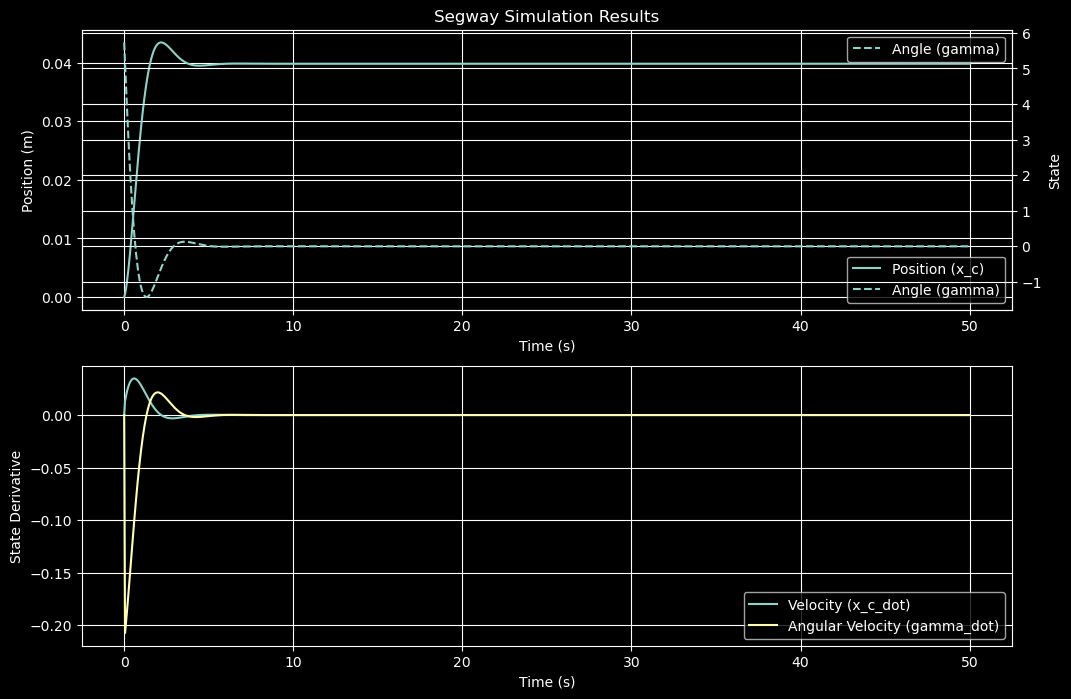

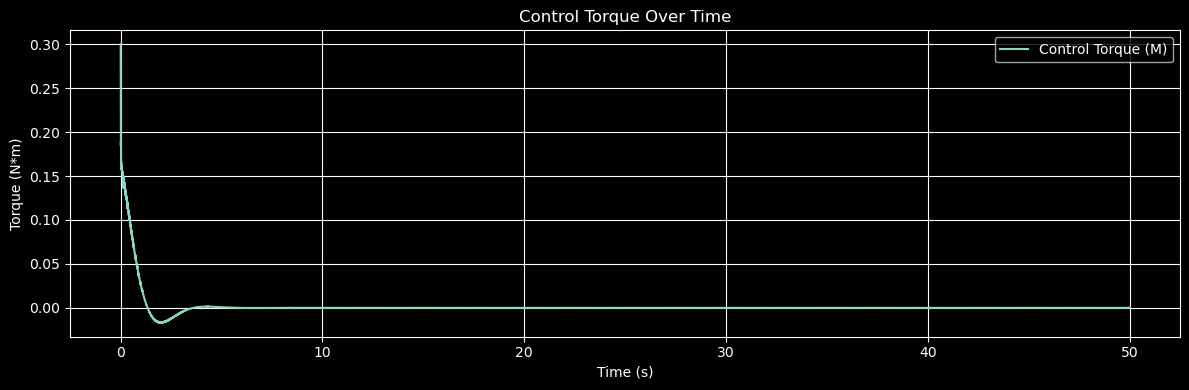

In [3]:
from Runner import run_simulation
from Parameters import params
from Config import CONTROL_MODE, MODEL_T, CONTROL_STRATEGY

print(params.m)

run_simulation(
    initial_state=[0.0, 0.0, 0.1, 0.0],
    time_span=(0, 50),
    control_mode=CONTROL_MODE.VELOCITY,
    controller_type=CONTROL_STRATEGY.PD,
    desired_gamma=0.0,
    desired_velocity=0.0,
    desired_position=4.0,
    model_type=MODEL_T.NONLINEAR_DAMP,
    record_Torque=True,
    export_CSV_flag=True,
)

In [ ]:
from Runner import run_simulation
from Parameters import params
from Config import CONTROL_MODE, MODEL_T, CONTROL_STRATEGY

print(params.m)

run_simulation(
    initial_state=[0.0, 0.0, 0.1, 0.0],
    time_span=(0, 50),
    control_mode=CONTROL_MODE.POSITION,
    controller_type=CONTROL_STRATEGY.PD,
    desired_gamma=0.0,
    desired_velocity=0.0,
    desired_position=4.0,
    model_type=MODEL_T.NONLINEAR_DAMP,
    record_Torque=True,
    export_CSV_flag=True,
)